In [1]:
# Cell 1 - Import necessary libraries and filter tickers by average daily dollar volume
import pandas as pd
import yfinance as yf
import os

# Define file paths for S&P 500 and NASDAQ datasets
sp500_file_path = 'sp500.csv'
nasdaq_file_path = 'nasdaq.csv'

# Load the data from the CSV files
sp500_data = pd.read_csv(sp500_file_path)
nasdaq_data = pd.read_csv(nasdaq_file_path)

# Display the first few rows of each dataset
print("S&P 500 Data Preview:")
display(sp500_data.head())

print("\nNASDAQ Data Preview:")
display(nasdaq_data.head())

# Display column names and data types for both datasets
print("\nS&P 500 Data Columns and Types:")
print(sp500_data.info())

print("\nNASDAQ Data Columns and Types:")
print(nasdaq_data.info())

# Function to calculate average daily dollar volume for each stock
def calculate_average_daily_dollar_volume(ticker):
    # Download historical data for the ticker
    stock_data = yf.download(ticker, start="1990-01-01")
    if stock_data.empty or 'Close' not in stock_data.columns or 'Volume' not in stock_data.columns:
        return None
    
    # Calculate daily dollar volume
    stock_data['Dollar_Volume'] = stock_data['Close'] * stock_data['Volume']
    avg_dollar_volume = stock_data['Dollar_Volume'].mean()
    
    return avg_dollar_volume

# Filter S&P 500 and NASDAQ tickers based on average daily dollar volume
filtered_sp500_tickers = []
for ticker in sp500_data['Ticker'].unique():
    avg_volume = calculate_average_daily_dollar_volume(ticker)
    if avg_volume and avg_volume >= 50_000_000:  # Check if average daily dollar volume is >= $50M
        filtered_sp500_tickers.append(ticker)
    else:
        print(f"Skipping {ticker} due to insufficient average daily dollar volume: {avg_volume}")

filtered_nasdaq_tickers = []
for ticker in nasdaq_data['Ticker'].unique():
    avg_volume = calculate_average_daily_dollar_volume(ticker)
    if avg_volume and avg_volume >= 50_000_000:
        filtered_nasdaq_tickers.append(ticker)
    else:
        print(f"Skipping {ticker} due to insufficient average daily dollar volume: {avg_volume}")

# Display the filtered tickers
print(f"\nFiltered S&P 500 Tickers: {filtered_sp500_tickers}")
print(f"\nFiltered NASDAQ Tickers: {filtered_nasdaq_tickers}")


S&P 500 Data Preview:


,Ticker
0,MMM



NASDAQ Data Preview:


,Ticker



S&P 500 Data Columns and Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Ticker  1 non-null      object
dtypes: object(1)
memory usage: 136.0+ bytes
None

NASDAQ Data Columns and Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 0 entries
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Ticker  0 non-null      object
dtypes: object(1)
memory usage: 124.0+ bytes
None


[*********************100%***********************]  1 of 1 completed


Filtered S&P 500 Tickers: ['MMM']

Filtered NASDAQ Tickers: []


In [2]:
# Cell 2 - Download and merge historical stock data with S&P 500 data

# Download S&P 500 historical prices using yfinance
sp500_prices = yf.download('^GSPC', start="1990-01-01")[['Close']].rename(columns={'Close': 'SP500_Close'})

# Define a function to download and merge historical stock data with S&P 500 data
def download_and_merge_data(ticker, sp500_prices, directory='data'):
    # Ensure the directory exists
    if not os.path.exists(directory):
        os.makedirs(directory)
        
    # Define the file path for the stock data
    file_path = f"{directory}/{ticker}.csv"
    
    # Check if the file already exists and skip download if it does
    if os.path.exists(file_path):
        print(f"Data for {ticker} already exists in {file_path}. Loading from file.")
        df = pd.read_csv(file_path, index_col=0, parse_dates=True)
    else:
        # Download the stock data using yfinance
        print(f"Downloading data for {ticker}...")
        df = yf.download(ticker, start="1990-01-01")
        
        # Check if the data contains the 'Close' column
        if df.empty or 'Close' not in df.columns:
            print(f"Data for {ticker} does not contain 'Close' column or is empty. Skipping.")
            return None
        
        # Save the downloaded data to a CSV file
        df.to_csv(file_path)
        print(f"Downloaded and saved data for {ticker}")

    # Merge the stock data with the S&P 500 data on the date index
    df = df.join(sp500_prices, how='inner')
    
    return df

# Use filtered tickers from Cell 1
# Download and merge data for filtered S&P 500 tickers
for ticker in filtered_sp500_tickers:
    merged_df = download_and_merge_data(ticker, sp500_prices)
    if merged_df is not None:
        # Display a sample of the merged data
        print(f"Sample data for {ticker}:")
        display(merged_df.head())

# Download and merge data for filtered NASDAQ tickers
for ticker in filtered_nasdaq_tickers:
    merged_df = download_and_merge_data(ticker, sp500_prices)
    if merged_df is not None:
        # Display a sample of the merged data
        print(f"Sample data for {ticker}:")
        display(merged_df.head())


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed

Downloaded and saved data for MMM
Sample data for MMM:


,Open,High,Low,Close,Adj Close,Volume,SP500_Close
Date,,,,,,,
1990-01-02,16.591764,16.853052,16.539507,16.826923,5.979101,1789216,359.690002
1990-01-03,16.853052,17.114340,16.826923,17.009825,6.044097,3147394,358.760010
1990-01-04,16.905310,17.349499,16.905310,17.140469,6.090518,3035926,355.670013
1990-01-05,17.062082,17.140469,16.853052,16.853052,5.988386,2183418,352.200012
1990-01-08,16.826923,17.323370,16.826923,17.297241,6.146221,2588622,353.790009


In [3]:
# Cell 3 - Clean and save the merged stock data

# Define a function to clean and save the merged stock data
def clean_and_save_merged_data(ticker, merged_df, directory='cleaned_data'):
    # Ensure the directory exists
    if not os.path.exists(directory):
        os.makedirs(directory)
        
    # Clean the data by dropping rows with missing values in essential columns
    cleaned_df = merged_df.dropna(subset=['Close', 'SP500_Close'])
    
    # Reset the index to include the 'Date' column
    cleaned_df.reset_index(inplace=True)
    
    # Save the cleaned data to a CSV file
    cleaned_file_path = f"{directory}/{ticker}_cleaned.csv"
    cleaned_df.to_csv(cleaned_file_path, index=False)
    print(f"Cleaned data saved for {ticker} in {cleaned_file_path}.")
    
    return cleaned_file_path

# List to store the cleaned file paths for S&P 500 and NASDAQ tickers
cleaned_sp500_files = []
cleaned_nasdaq_files = []

# Clean and save data for filtered S&P 500 tickers
for ticker in filtered_sp500_tickers:
    merged_df = download_and_merge_data(ticker, sp500_prices)  # Use merged data from Cell 2
    if merged_df is not None:
        cleaned_file = clean_and_save_merged_data(ticker, merged_df)
        cleaned_sp500_files.append(cleaned_file)

# Clean and save data for filtered NASDAQ tickers
for ticker in filtered_nasdaq_tickers:
    merged_df = download_and_merge_data(ticker, sp500_prices)  # Use merged data from Cell 2
    if merged_df is not None:
        cleaned_file = clean_and_save_merged_data(ticker, merged_df)
        cleaned_nasdaq_files.append(cleaned_file)

# Display cleaned files summary
print("Cleaned S&P 500 Files:")
for file in cleaned_sp500_files:
    print(file)
    df = pd.read_csv(file)
    display(df.head())

print("\nCleaned NASDAQ Files:")
for file in cleaned_nasdaq_files:
    print(file)
    df = pd.read_csv(file)
    display(df.head())


Data for MMM already exists in data/MMM.csv. Loading from file.
Cleaned data saved for MMM in cleaned_data/MMM_cleaned.csv.
Cleaned S&P 500 Files:
cleaned_data/MMM_cleaned.csv


,Date,Open,High,Low,Close,Adj Close,Volume,SP500_Close
0,1990-01-02,16.591764,16.853052,16.539507,16.826923,5.979101,1789216,359.690002
1,1990-01-03,16.853052,17.114340,16.826923,17.009825,6.044097,3147394,358.760010
2,1990-01-04,16.905310,17.349499,16.905310,17.140469,6.090518,3035926,355.670013
3,1990-01-05,17.062082,17.140469,16.853052,16.853052,5.988386,2183418,352.200012
4,1990-01-08,16.826923,17.323370,16.826923,17.297241,6.146221,2588622,353.790009



Cleaned NASDAQ Files:


In [4]:
# Cell 4 - Verify the cleaned data files for both S&P 500 and NASDAQ

# Verify and display cleaned data files for both S&P 500 and NASDAQ
print("Cleaned S&P 500 Files Verification:")

for file in cleaned_sp500_files:
    print(f"Verifying {file}...")
    try:
        # Read the cleaned data file
        df = pd.read_csv(file)
        
        # Display basic information about the cleaned file
        print(f"File: {file}")
        print(f"Number of rows: {df.shape[0]}")
        print(f"Number of columns: {df.shape[1]}")
        print(f"Column Names: {list(df.columns)}")
        
        # Display the first few rows for visual verification
        display(df.head())
    except Exception as e:
        print(f"Error reading {file}: {e}")

print("\nCleaned NASDAQ Files Verification:")

for file in cleaned_nasdaq_files:
    print(f"Verifying {file}...")
    try:
        # Read the cleaned data file
        df = pd.read_csv(file)
        
        # Display basic information about the cleaned file
        print(f"File: {file}")
        print(f"Number of rows: {df.shape[0]}")
        print(f"Number of columns: {df.shape[1]}")
        print(f"Column Names: {list(df.columns)}")
        
        # Display the first few rows for visual verification
        display(df.head())
    except Exception as e:
        print(f"Error reading {file}: {e}")


Cleaned S&P 500 Files Verification:
Verifying cleaned_data/MMM_cleaned.csv...
File: cleaned_data/MMM_cleaned.csv
Number of rows: 8795
Number of columns: 8
Column Names: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'SP500_Close']


,Date,Open,High,Low,Close,Adj Close,Volume,SP500_Close
0,1990-01-02,16.591764,16.853052,16.539507,16.826923,5.979101,1789216,359.690002
1,1990-01-03,16.853052,17.114340,16.826923,17.009825,6.044097,3147394,358.760010
2,1990-01-04,16.905310,17.349499,16.905310,17.140469,6.090518,3035926,355.670013
3,1990-01-05,17.062082,17.140469,16.853052,16.853052,5.988386,2183418,352.200012
4,1990-01-08,16.826923,17.323370,16.826923,17.297241,6.146221,2588622,353.790009



Cleaned NASDAQ Files Verification:


# TEST

In [5]:
# New Cell - Calculate and Save Stop Loss and Trailing Stop Prices

# Define function to calculate Stop Loss and Trailing Stop prices for each stock
def add_stop_prices(df):
    # Calculate 20-day ATR for Stop Loss calculation
    df['ATR_20'] = df['High'].rolling(window=20).apply(lambda x: x.max() - x.min())
    
    # Calculate Stop Loss Price: Entry Price - (5 * ATR_20)
    df['Stop_Loss_Price'] = df['Close'] - (5 * df['ATR_20'])
    
    # Calculate Trailing Stop Price: 0.75 * max 'High' since entry
    df['Trailing_Stop_Price'] = df['High'].expanding().max() * 0.75
    
    return df

# Add Stop Loss and Trailing Stop Prices to each cleaned data file
for file in cleaned_sp500_files + cleaned_nasdaq_files:
    df = pd.read_csv(file, index_col='Date', parse_dates=True)
    df = add_stop_prices(df)
    df.to_csv(file)  # Save back with Stop Loss and Trailing Stop prices
    print(f"Updated file with Stop Loss and Trailing Stop Prices: {file}")


Updated file with Stop Loss and Trailing Stop Prices: cleaned_data/MMM_cleaned.csv


In [6]:
# Cell 4.5 - Check for data points, NaN values, and verify if there's enough data (more than 20 points)

import os
import pandas as pd

# Define a function to check the number of data points and NaN values in each cleaned file
def check_data_points_and_nan(cleaned_files):
    for cleaned_file in cleaned_files:
        try:
            # Load the stock data from the cleaned file
            stock_data = pd.read_csv(cleaned_file, index_col='Date', parse_dates=True)
            
            # Count the number of data points (rows) in the stock data
            num_data_points = len(stock_data)
            
            # Check if there are any NaN values in the necessary columns
            required_columns = ['Close', 'High', 'Low']
            nan_columns = stock_data[required_columns].isna().sum()
            
            # Print the result
            if num_data_points >= 20:
                print(f"{os.path.basename(cleaned_file)} has {num_data_points} data points. Sufficient for ATR calculation.")
                if nan_columns.sum() > 0:
                    print(f"Warning: {os.path.basename(cleaned_file)} has NaN values in the following columns: {nan_columns[nan_columns > 0]}")
                else:
                    print(f"{os.path.basename(cleaned_file)} has no NaN values in 'Close', 'High', and 'Low' columns.")
            else:
                print(f"{os.path.basename(cleaned_file)} has {num_data_points} data points. Not sufficient for ATR calculation.")
        
        except Exception as e:
            print(f"Error processing {cleaned_file}: {e}")

# Call the function to check data points and NaN values for all cleaned files
check_data_points_and_nan(cleaned_sp500_files)  # Check for S&P 500 cleaned files
check_data_points_and_nan(cleaned_nasdaq_files)  # Check for NASDAQ cleaned files


MMM_cleaned.csv has 8795 data points. Sufficient for ATR calculation.
MMM_cleaned.csv has no NaN values in 'Close', 'High', and 'Low' columns.


c:\Users\Abdul Rehman\AppData\Local\Programs\Python\Python310\lib\site-packages\backtesting\backtesting.py:1488: UserWarning: Searching for best of 405 configurations.
  output = _optimize_grid()


  0%|          | 0/9 [00:00<?, ?it/s]

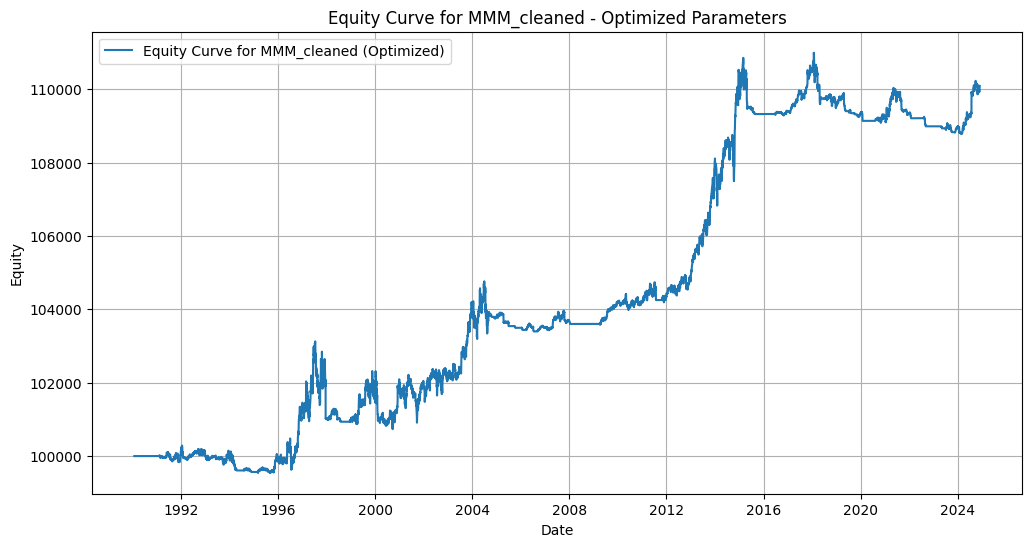

In [7]:
# Cell 5 - Run optimized backtest on the cleaned data files, plot results, and save trade logs

from backtesting import Backtest, Strategy
from backtesting.lib import crossover
import pandas as pd
import matplotlib.pyplot as plt
import os

# Create a directory to store trade logs if it doesn't exist
trade_log_directory = "Trade Log"
os.makedirs(trade_log_directory, exist_ok=True)

# Define a function to calculate the 200-day rate of change for ranking stocks
def calculate_roc_200(stock_data):
    if len(stock_data) >= 200:
        roc = (stock_data['Close'].iloc[-1] - stock_data['Close'].iloc[-200]) / stock_data['Close'].iloc[-200]
        return roc
    return -float('inf')  # Handle cases where the data has less than 200 rows

# Define the trading strategy with optimizable parameters
class LongTrendHighMomentum(Strategy):
    n1 = 25  # Short SMA period
    n2 = 50  # Long SMA period
    n_sp500 = 100  # S&P 500 SMA period
    risk_per_position = 0.02
    max_position_size = 0.10
    max_positions = 10
    trailing_stop_pct = 0.25  # Trailing stop percent
    stock_price_threshold = 5

    def init(self):
        if 'SP500_Close' not in self.data.df.columns:
            raise KeyError("The 'SP500_Close' column is missing from the data.")
        
        self.sma_short = self.I(lambda x: pd.Series(x).rolling(self.n1).mean(), self.data.Close)
        self.sma_long = self.I(lambda x: pd.Series(x).rolling(self.n2).mean(), self.data.Close)
        self.sma_sp500 = self.I(lambda x: pd.Series(x).rolling(self.n_sp500).mean(), self.data['SP500_Close'])
        self.high_since_entry = 0
        self.entry_stop_loss = None
        self.stopped_out = False  # Track if stop loss was triggered
        self.pending_buy = False  # Flag to track if a buy should occur on the next open

    def next(self):
        # Filter based on stock price threshold
        if pd.isna(self.data.Close[-1]) or self.data.Close[-1] <= self.stock_price_threshold:
            return

        # Check S&P 500 100-day SMA condition
        if pd.isna(self.sma_sp500[-1]) or self.data['SP500_Close'][-1] <= self.sma_sp500[-1]:
            return

        if len(self.data.Close) < 20:
            return

        # Calculate ATR (Average True Range)
        true_range_values = [
            self.data.High[-1] - self.data.Low[-1],
            abs(self.data.High[-1] - self.data.Close[-2]),
            abs(self.data.Close[-2] - self.data.Low[-1])
        ]
        atr = max(true_range_values)

        # If ATR is NaN or 0, calculate it using the last valid ATR value
        if pd.isna(atr) or atr == 0:
            atr = self.data.ATR[-1] if hasattr(self.data, 'ATR') and not pd.isna(self.data.ATR[-1]) else 0.1  # Fallback value

        # Exit if ATR is still 0 or NaN after fallback
        if atr == 0:
            return

        # Entry logic with reentry check
        if self.pending_buy and len(self.trades) < self.max_positions:  # If buy is pending and position limit not exceeded
            entry_price = self.data.Open[-1]  # Buy at the next open
            position_size = min(
                (self.equity * self.risk_per_position) / entry_price,
                (self.equity * self.max_position_size) / entry_price
            )
            self.entry_stop_loss = entry_price - 5 * atr
            self.buy(size=int(position_size), sl=self.entry_stop_loss)
            self.high_since_entry = self.data.High[-1]
            self.stopped_out = False  # Reset stop-out flag upon reentry
            self.pending_buy = False  # Reset pending buy flag

        elif (self.stopped_out or crossover(self.sma_short, self.sma_long)) and len(self.trades) < self.max_positions:
            self.pending_buy = True  # Set pending buy flag to enter on the next open

        if self.position:
            self.high_since_entry = max(self.high_since_entry, self.data.High[-1])
            trailing_stop = self.high_since_entry * (1 - self.trailing_stop_pct)

            # Ensure Stop Loss has priority over Trailing Stop
            if self.data.Low[-1] < self.entry_stop_loss:
                self.stopped_out = True  # Set flag to allow reentry if conditions are met
                self.position.close()
            elif self.data.Low[-1] < trailing_stop:
                self.position.close()

    def on_exit(self, position):
        if self.stopped_out and crossover(self.sma_short, self.sma_long):
            self.buy()

# Define a function to run optimized backtests and return the best parameters
def optimize_backtest(cleaned_files, cash=100000, commission=0.0):
    results_list = []
    ranked_files = sorted(
        cleaned_files, 
        key=lambda f: calculate_roc_200(pd.read_csv(f, index_col='Date', parse_dates=True)), 
        reverse=True
    )

    for cleaned_file in ranked_files[:10]:  # Limit to top 10 stocks by ROC
        try:
            stock_data = pd.read_csv(cleaned_file, index_col='Date', parse_dates=True)

            required_columns = ['Close', 'High', 'Low', 'SP500_Close']
            if not all(col in stock_data.columns for col in required_columns):
                continue
            stock_data = stock_data.dropna()

            if len(stock_data) < max(200, LongTrendHighMomentum.n_sp500):
                continue

            # **Fix: Correct ATR Calculation using the entire column**
            # Calculate the True Range for each row
            stock_data['True_Range'] = pd.concat([ 
                stock_data['High'] - stock_data['Low'], 
                (stock_data['High'] - stock_data['Close'].shift(1)).abs(),
                (stock_data['Close'].shift(1) - stock_data['Low']).abs()
            ], axis=1).max(axis=1)

            # Calculate the rolling average of True Range (ATR) over the last 20 periods
            stock_data['ATR'] = stock_data['True_Range'].rolling(window=20).mean()

            bt = Backtest(stock_data, LongTrendHighMomentum, cash=cash, commission=commission)

            optimized_stats = bt.optimize(
                n1=range(10, 40, 5),
                n2=range(30, 70, 5),
                risk_per_position=[0.01, 0.02, 0.03],
                trailing_stop_pct=[0.2, 0.25, 0.3],
                maximize='Sharpe Ratio',
                constraint=lambda param: param.n1 < param.n2
            )

            results_list.append({
                'Filename': cleaned_file,
                'Equity Final [$]': optimized_stats['Equity Final [$]'],
                'Return [%]': optimized_stats['Return [%]'],
                'Max. Drawdown [%]': optimized_stats['Max. Drawdown [%]'],
                'Sharpe Ratio': optimized_stats['Sharpe Ratio'],
                'Win Rate [%]': optimized_stats['Win Rate [%]'],
                'Trades': optimized_stats['_trades']
            })

            trades_df = optimized_stats['_trades']
            timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
            ticker_name = os.path.basename(cleaned_file).split('.')[0]
            trade_log_filename = f"lthm_trade_log_{ticker_name}_{timestamp}.csv"
            trade_log_path = os.path.join(trade_log_directory, trade_log_filename)
            trades_df.to_csv(trade_log_path, index=False)

            equity_curve = optimized_stats['_equity_curve']
            plt.figure(figsize=(12, 6))
            plt.plot(equity_curve['Equity'], label=f"Equity Curve for {ticker_name} (Optimized)")
            plt.xlabel("Date")
            plt.ylabel("Equity")
            plt.title(f"Equity Curve for {ticker_name} - Optimized Parameters")
            plt.legend()
            plt.grid(True)
            plt.show()

        except Exception as e:
            print(f"Error processing {cleaned_file}: {e}")

    return results_list

# Run the optimization for both S&P 500 and NASDAQ tickers
optimized_sp500_results = optimize_backtest(cleaned_sp500_files)
optimized_nasdaq_results = optimize_backtest(cleaned_nasdaq_files)


Available columns in results_df: Index(['Filename', 'Equity Final [$]', 'Return [%]', 'Max. Drawdown [%]',
       'Sharpe Ratio', 'Win Rate [%]', 'Trades'],
      dtype='object')
Summary of Backtesting Results:
                       Filename  Equity Final [$]  Return [%]  \
0  cleaned_data/MMM_cleaned.csv     110092.633514   10.092634   

   Max. Drawdown [%]  Sharpe Ratio  Win Rate [%]  \
0          -2.320278      0.326121     41.176471   

                                              Trades  
0       Size  EntryBar  ExitBar  EntryPrice   Exi...  
Results saved to SP500_Strategy_Backtest_Results_20241129_090545.csv


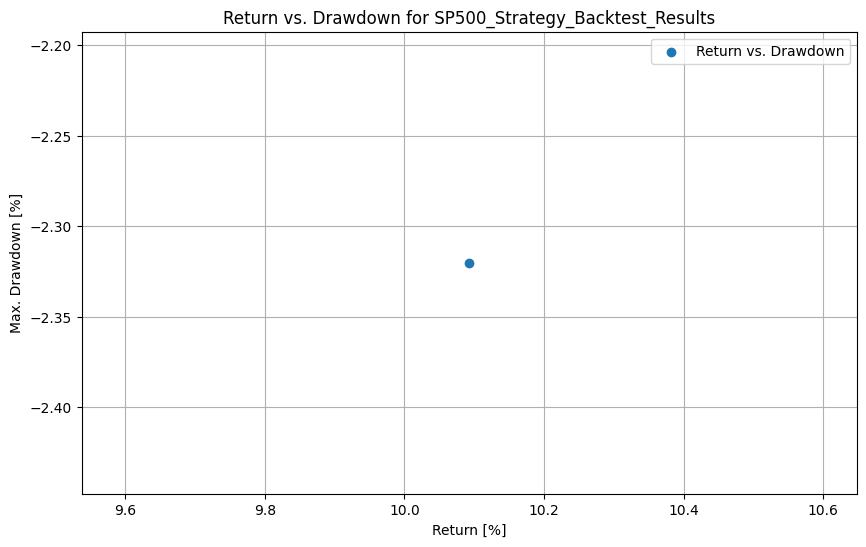

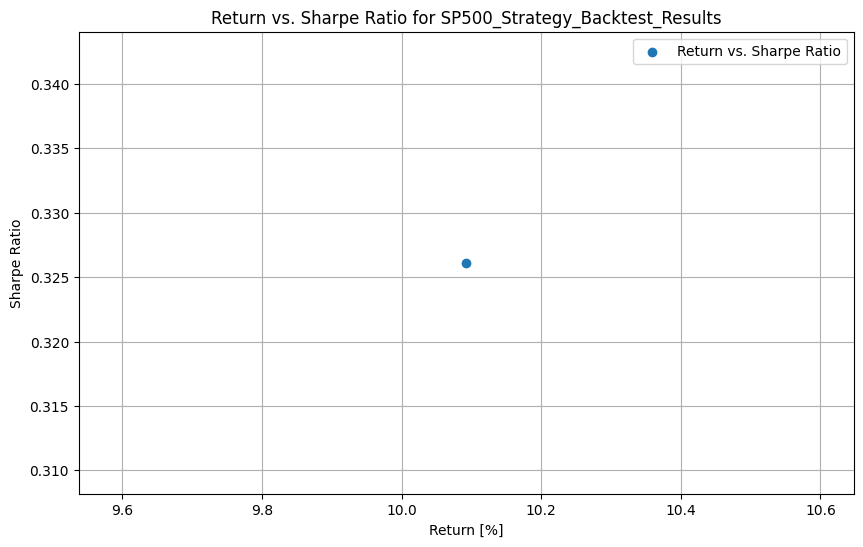

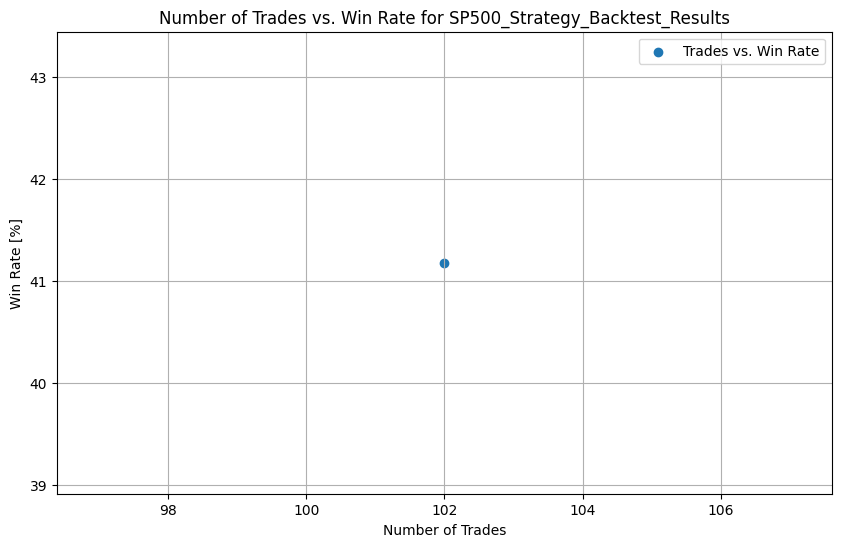

Available columns in results_df: RangeIndex(start=0, stop=0, step=1)
Summary of Backtesting Results:
Empty DataFrame
Columns: []
Index: []
Results saved to NASDAQ_Strategy_Backtest_Results_20241129_090545.csv


In [8]:
# Cell 6 - Analysis and Visualization of Backtesting Results

import pandas as pd
import matplotlib.pyplot as plt

# Define a function to analyze backtesting results and generate visualizations
def analyze_results(stats_list, output_file_name):
    # Convert stats to DataFrame for easier analysis
    results_df = pd.DataFrame(stats_list)
    
    # Display available columns in results_df
    print(f"Available columns in results_df: {results_df.columns}")

    # Check and select columns that are available in results_df
    columns_to_display = [col for col in ['Filename', 'Equity Final [$]', 'Return [%]', 'Max. Drawdown [%]', 'Sharpe Ratio', 'Win Rate [%]', 'Trades'] if col in results_df.columns]
    
    # Display key statistics in a summary format if columns are available
    print("Summary of Backtesting Results:")
    print(results_df[columns_to_display])

    # Save the detailed results to a CSV file with a timestamped name
    timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
    results_df.to_csv(f"{output_file_name}_{timestamp}.csv", index=False)
    print(f"Results saved to {output_file_name}_{timestamp}.csv")

    # Plot Return vs. Drawdown for a visual overview, if available
    if 'Return [%]' in results_df.columns and 'Max. Drawdown [%]' in results_df.columns:
        plt.figure(figsize=(10, 6))
        plt.scatter(results_df['Return [%]'], results_df['Max. Drawdown [%]'], label='Return vs. Drawdown')
        plt.xlabel('Return [%]')
        plt.ylabel('Max. Drawdown [%]')
        plt.title(f'Return vs. Drawdown for {output_file_name}')
        plt.grid(True)
        plt.legend()
        plt.show()

    # Plot Sharpe Ratio vs. Return, if available
    if 'Return [%]' in results_df.columns and 'Sharpe Ratio' in results_df.columns:
        plt.figure(figsize=(10, 6))
        plt.scatter(results_df['Return [%]'], results_df['Sharpe Ratio'], label='Return vs. Sharpe Ratio')
        plt.xlabel('Return [%]')
        plt.ylabel('Sharpe Ratio')
        plt.title(f'Return vs. Sharpe Ratio for {output_file_name}')
        plt.grid(True)
        plt.legend()
        plt.show()

    # Plot number of trades vs. win rate, if available
    if 'Trades' in results_df.columns and 'Win Rate [%]' in results_df.columns:
        plt.figure(figsize=(10, 6))
        plt.scatter(results_df['Trades'].apply(len), results_df['Win Rate [%]'], label='Trades vs. Win Rate')
        plt.xlabel('Number of Trades')
        plt.ylabel('Win Rate [%]')
        plt.title(f'Number of Trades vs. Win Rate for {output_file_name}')
        plt.grid(True)
        plt.legend()
        plt.show()

# Analyze results for S&P 500 and NASDAQ backtest results
analyze_results(optimized_sp500_results, output_file_name="SP500_Strategy_Backtest_Results")
analyze_results(optimized_nasdaq_results, output_file_name="NASDAQ_Strategy_Backtest_Results")


In [9]:
# Cell 7 - Live Execution for Generating Daily Trade List Based on Previous Day's Close

from datetime import datetime, timedelta

# Define a function to fetch yesterday's closing prices and filter stocks for live trading
def fetch_and_filter_live_tickers(sp500_file, nasdaq_file, min_dollar_volume=50_000_000):
    sp500_data = pd.read_csv(sp500_file)
    nasdaq_data = pd.read_csv(nasdaq_file)
    
    filtered_sp500_tickers = []
    filtered_nasdaq_tickers = []
    
    for ticker in sp500_data['Ticker'].unique():
        avg_volume = calculate_average_daily_dollar_volume(ticker)
        if avg_volume and avg_volume >= min_dollar_volume:
            filtered_sp500_tickers.append(ticker)

    for ticker in nasdaq_data['Ticker'].unique():
        avg_volume = calculate_average_daily_dollar_volume(ticker)
        if avg_volume and avg_volume >= min_dollar_volume:
            filtered_nasdaq_tickers.append(ticker)

    return filtered_sp500_tickers, filtered_nasdaq_tickers

# Function to generate daily trade list
def generate_daily_trade_list(filtered_tickers, sp500_close, date=None):
    trade_list = []
    for ticker in filtered_tickers:
        stock_data = yf.download(ticker, start=date, end=date + timedelta(days=1))  # Fetch latest data
        if not stock_data.empty and stock_data['Close'].iloc[0] > 5:
            # Add logic here to determine buy/sell signals based on previous day's close
            # For simplicity, assuming a buy signal if price is above 5
            trade_list.append({"Ticker": ticker, "Action": "Buy"})

    return trade_list

# Main function for live execution
def run_live_execution(sp500_file='sp500.csv', nasdaq_file='nasdaq.csv'):
    date = datetime.now() - timedelta(days=1)
    sp500_close = yf.download('^GSPC', start=date, end=date + timedelta(days=1))['Close'].iloc[0]

    # Fetch and filter tickers based on live data
    filtered_sp500_tickers, filtered_nasdaq_tickers = fetch_and_filter_live_tickers(sp500_file, nasdaq_file)

    # Generate trade list for S&P 500
    sp500_trades = generate_daily_trade_list(filtered_sp500_tickers, sp500_close, date)
    nasdaq_trades = generate_daily_trade_list(filtered_nasdaq_tickers, sp500_close, date)

    # Save trade list to a CSV file
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"daily_trade_list_{timestamp}.csv"
    pd.DataFrame(sp500_trades + nasdaq_trades).to_csv(filename, index=False)
    print(f"Daily trade list saved as {filename}")

# Run the live execution function
run_live_execution()


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Daily trade list saved as daily_trade_list_20241129_090549.csv
